In [2]:
from tqdm import tqdm_notebook
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import nibabel as nb
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler 
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from nilearn.maskers import NiftiMasker
from nilearn import image
from scipy.interpolate import interp1d
from nilearn.image import index_img

mask_names = ['mofc','lofc','hp','dlPFC','FFA/PPA']

subject_inds = [1,2,3,4,5,7,8,9,10,11,12,14,15,16,17,18,20,21,22,23,24,25,26,27,28,29,30]
categories = np.array(['(Fy)Fo', '(Fo)Fy', '(Hy)Ho', '(Ho)Hy', '(Fy)Fy', '(Fo)Fo', '(Hy)Hy', '(Ho)Ho', '(Fy)Hy', '(Fy)Ho', '(Fo)Hy', '(Fo)Ho', '(Hy)Fy', '(Hy)Fo', '(Ho)Fy', '(Ho)Fo'])


conditions = np.array(['pre_irre_age','pre_irre_category'])
index = pd.MultiIndex.from_product([subject_inds, mask_names, conditions], names=['subject', 'mask_name', 'condition'])
df_scores = pd.DataFrame(index=index, columns=['score', 'chance_score'])

for current_subject in tqdm_notebook(subject_inds):
    print("The current subject is %s" % current_subject)
    data_dir = f'/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/'
    all_beta = f"{data_dir}/sub-{current_subject:02}_beta.nii.gz"
    datasets = {"mofc":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/mofc_bin.nii.gz"],
                "lofc":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/lofc_bin.nii.gz"],
                "hp":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/hp_bin.nii.gz"],
                #"dlPFC":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/dlPFC_bin.nii.gz"],
                "dlPFC":[f"/home/garlicseed/Mount/final/beta/dlpfc_bin.nii.gz"],
                "FFA/PPA":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/FFA-PPA_bin.nii.gz"],
                #"R_mofc":[f"/home/garlicseed/Mount/final/beta/sub-{current_subject:02}/R_mofc_bin.nii.gz"]
               }
    
    labels = pd.read_csv('/home/garlicseed/Mount/final/beta/sub-{:02d}/sub-{:02}_events.tsv'.format(current_subject,current_subject),sep='\t')    
    need = labels["state_irre"]
    condition_mask = ~need.isin(['0'])
    fmri_niimgs = index_img(all_beta, condition_mask)
    labels = labels[condition_mask].reset_index()
    data = fmri_niimgs.get_fdata()

    
    state_beta = []
    # 初始化一个空的列表来存储所有的category名称和对应的run
    state_names = []
    run_numbers = []

    # 对每个run进行循环
    for run in np.unique(labels['run']):
        # 对每个category进行循环
        for category in categories:
            # 获取当前run和category的trial索引
            indices = labels[(labels['run'] == run) & (labels['state_irre'] == category)].index

            # 检查是否有trial属于当前的run和category
            if len(indices) > 0:
                # 如果有，提取出这些trial的数据，并计算平均值
                avg_beta_map_data = np.mean(data[..., indices], axis=-1, keepdims=True)

                # 创建一个新的 Nifti1Image 对象
                avg_beta_map_img = image.new_img_like(fmri_niimgs, avg_beta_map_data)

                # 将平均beta map添加到列表中
                state_beta.append(avg_beta_map_img)

                # 将category名称和对应的run添加到列表中
                state_names.append(category)
                run_numbers.append(run)

    # 将所有的平均beta map叠加在一起
    state_beta = image.concat_imgs(state_beta)

    # 创建一个DataFrame来存储所有的category名称和对应的run
    df = pd.DataFrame({'state_irre': state_names, 'run': run_numbers})
    # 拆分列
    df[['dimA_shifted','dimA']] = df['state_irre'].str.extract(r'\((.*?)\)(.*)')
    # 创建一个DataFrame来存储所有的category名称
    df['pre_irre_age'] = df['dimA_shifted'].replace({'Fo':'old', 'Fy':'young', 'Hy':'young', 'Ho':'old'})
    df['pre_irre_category'] = df['dimA_shifted'].replace({'Fo':'face', 'Fy':'face', 'Hy':'house', 'Ho':'house'})
    labels_run = df['run']
    session_labels = labels_run
    
    for mask_name in tqdm_notebook(mask_names):
        print("The current subject is %s, Working on  %s" % (current_subject, mask_name))
        mask_filename = datasets[mask_name][0]
        masker = NiftiMasker(
            mask_img=mask_filename,
            standardize="zscore_sample",
            runs=session_labels,
            smoothing_fwhm=4,
            t_r=1.5,
            memory="nilearn_cache",
            memory_level=1,
                 )
        fmri_masked = masker.fit_transform(state_beta)
    
        for condition in tqdm_notebook(conditions):
            print("current condition is on %s" % condition)
            labels_stim = df[condition]
            from sklearn.preprocessing import LabelEncoder
            encoder = LabelEncoder()
            condi = encoder.fit_transform(labels_stim)
        
        
            from sklearn.model_selection import LeaveOneGroupOut
            logo = LeaveOneGroupOut()                        
            from sklearn.svm import SVC
            from sklearn.model_selection import cross_val_score
            from sklearn.dummy import DummyClassifier
            from sklearn.metrics import accuracy_score
            pipeline = Pipeline(
                [
                    #("anova", SelectKBest(f_classif, k='all')),
                    #('scaler', StandardScaler()),
                    ("svc", SVC(kernel='linear',C=0.001)),
                ]
            )
            performance_svc = []
            performance_dummy = []
            for train_idx, test_idx in logo.split(fmri_masked, condi, session_labels):
                X_train, X_test = fmri_masked[train_idx, :], fmri_masked[test_idx, :]
                y_train, y_test = condi[train_idx], condi[test_idx]
                pipeline.fit(X_train, y_train)
                dummy = DummyClassifier()
                dummy.fit(X_train, y_train)
                # 在每次迭代中对测试集进行预测，并将预测结果保存到列表中
                y_pred = pipeline.predict(X_test)
                y_pred = np.squeeze(y_pred)
                performance_svc.append(accuracy_score(y_test, y_pred))

                y_pred_dummy = dummy.predict(X_test)
                y_pred_dummy = np.squeeze(y_pred_dummy)
                performance_dummy.append(accuracy_score(y_test, y_pred_dummy)) 
            # 对所有迭代的预测结果进行平均，以得到最终的预测结果
            y_pred_final_svc = np.mean(performance_svc, axis=0)
            y_pred_final_dummy = np.mean(performance_dummy, axis=0)
            df_scores.loc[(current_subject, mask_name, condition), 'score'] = y_pred_final_svc
            df_scores.loc[(current_subject, mask_name, condition), 'chance_score'] = y_pred_final_dummy
           
            print("Scores: %1.2f +- %1.2f" % (np.mean(performance_svc), np.std(performance_svc)))
            print("Chacne Scores: %1.2f +- %1.2f" % (np.mean(performance_dummy), np.std(performance_dummy)))            

df_scores = df_scores.reset_index()            
df_mean = df_scores.groupby(['mask_name', 'condition'])[['score', 'chance_score']].mean()            
df_mean = df_mean.reset_index()                             
df_scores.to_csv('/home/garlicseed/Mount/final/MVPA/2category_irrelevent/Sorces/two_trials_ago_accuray.tsv',sep='\t')
df_scores.to_csv('/media/garlicseed/data/final/MVPA/2category_irrelevent/Sorces/two_trials_ago_accuray.tsv',sep='\t')

  0%|          | 0/27 [00:00<?, ?it/s]

The current subject is 1


  0%|          | 0/5 [00:00<?, ?it/s]

The current subject is 1, Working on  mofc


  0%|          | 0/2 [00:00<?, ?it/s]

...

current condition is on pre_irre_age
Scores: 0.53 +- 0.05
Chacne Scores: 0.50 +- 0.00
current condition is on pre_irre_category
Scores: 0.64 +- 0.09
Chacne Scores: 0.50 +- 0.00
The current subject is 30, Working on  dlPFC


  0%|          | 0/2 [00:00<?, ?it/s]

current condition is on pre_irre_age
Scores: 0.56 +- 0.10
Chacne Scores: 0.50 +- 0.00
current condition is on pre_irre_category
Scores: 0.50 +- 0.08
Chacne Scores: 0.50 +- 0.00
The current subject is 30, Working on  FFA/PPA


  0%|          | 0/2 [00:00<?, ?it/s]

current condition is on pre_irre_age
Scores: 0.42 +- 0.12
Chacne Scores: 0.50 +- 0.00
current condition is on pre_irre_category
Scores: 0.70 +- 0.05
Chacne Scores: 0.50 +- 0.00


pre_age-lofc : 	 p= 0.2063 mu=0.5223
pre_age-mofc : 	 p= 0.2989 mu=0.5206
pre_category-lofc : 	 p= 0.5371 mu=0.5090
pre_category-mofc : 	 p= 0.4622 mu=0.5108


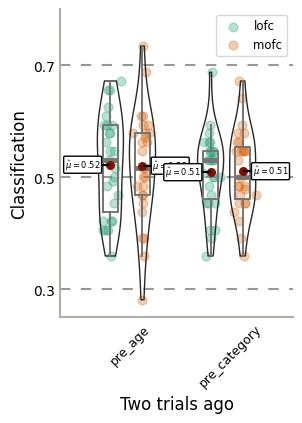

In [16]:
#Plot irrelevent_two_trials_age
import pandas as pd
#df_scores =pd.read_csv('/home/garlicseed/Mount/final/MVPA/2category_irrelevent/Sorces/accuray.tsv',sep='\t')
df_scores = df_scores[df_scores['mask_name'] != 'hp']
df_scores['condition'] = df_scores['condition'].replace('pre_irre_category', 'pre_category')
df_scores['condition'] = df_scores['condition'].replace('pre_irre_age', 'pre_age')
from mlxtend.evaluate import permutation_test
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as st
BG_WHITE = "#fbf9f4"
GREY_LIGHT = "#b4aea9"
GREY50 = "#7F7F7F"
BLUE_DARK = "#1B2838"
BLUE = "#2a475e"
BLACK = "#282724"
GREY_DARK = "#747473"
RED_DARK = "#850e00"
mask_names = sorted(df_scores["mask_name"].unique())
conditions = sorted(df_scores["condition"].unique())

fig, ax = plt.subplots(figsize=(3,4))
jitter_dot = 0.025
jitter = 0.32  # Increase the jitter or separation between mofc and lofc
HLINES = [0.3 , 0.5, 0.7]
COLOR_SCALE = ["#1B9E77", "#D95F02"]
#fig.patch.set_facecolor(BG_WHITE)
#ax.set_facecolor(BG_WHITE)

# Horizontal lines that are used as scale reference
for h in HLINES:
    ax.axhline(h, color=GREY50, ls=(0, (5, 5)), alpha=0.8, zorder=0)
for i, condition in enumerate(conditions):
    for j, mask_name in enumerate(mask_names):
        y_data = df_scores[(df_scores["mask_name"] == mask_name) & (df_scores["condition"] == condition)]["score"].values.astype(float)
        y_base = np.full_like(y_data, 0.5)
        #t, p = ttest_1samp(y_data, 0.5)
        p = permutation_test(y_data, y_base,
                           method='approximate',
                           num_rounds=10000,
                           seed=0)
        print(f'{condition}-{mask_name} : \t p= {p:.4f} mu={y_data.mean():.4f}')

        ts = ''
        if p < 0.05:
            if p < (0.0001 ):
                ts = '*' * 4
            elif p < (0.001 ):
                ts = '*' * 3
            elif p < (0.01 ):
                ts = '*' * 2
            elif p < (0.05 ):
                ts = '*'        
        x_data = np.array([i + j * jitter] * len(y_data))
        x_data = x_data + st.t(df=6, scale=jitter_dot).rvs(len(x_data)) # add jittering to the x_data
        ax.scatter(x_data, y_data, s = 40, color=COLOR_SCALE[j], alpha=0.3, label=mask_name if i == 0 else "")
        
        mean_val = y_data.mean() # Calculate the mean
        ax.scatter(i + j * jitter, mean_val, s=30, color=RED_DARK, zorder=3) # Add red dot for mean
        if mask_name == "mofc":
            ha = 'left'
            pos = i + j * jitter + 0.1
            ax.plot([i + j * jitter, pos], [mean_val, mean_val], ls="dashdot", color="black", zorder=3)
        else:
            ha = 'right'
            pos = i + j * jitter - 0.1
            ax.plot([pos, i + j * jitter], [mean_val, mean_val], ls="dashdot", color="black", zorder=3)
        ax.text(pos, mean_val, r"$\hat{\mu} = $" + str(round(mean_val, 2)), fontsize=6, va="center",color="black", ha=ha,bbox = dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round",
            pad=0.15
        ),zorder=10)        
        
        
        violins = ax.violinplot(y_data, positions=[i + j * jitter], widths=0.26,
                                bw_method="silverman", showmeans=False, showmedians=False, showextrema=False)
        for pc in violins["bodies"]:
            pc.set_facecolor('none')
            pc.set_edgecolor(BLACK)
            pc.set_linewidth(1)
            pc.set_alpha(1)
            
        boxprops = dict(linewidth=1.4, color=GREY_DARK)
        medianprops = dict(linewidth=3.5, color=GREY_DARK, solid_capstyle="butt")
        ax.boxplot(y_data, positions=[i + j * jitter], widths=0.15, showcaps=False, 
                    boxprops=boxprops, medianprops=medianprops, whiskerprops=boxprops, showfliers=False)
        
        ax.text(i + j * jitter + 0.1-0.09 , np.max(y_data)+0.01, ts, {'fontsize': 10, 'ha': 'center', 'fontweight': 'normal'})        

# Adjust the x ticks position and labels to be in the middle of mofc and lofc
ax.set_xticks(np.arange(0.2, len(conditions), 1))
ax.set_xticklabels(conditions, size=9, ha="center", ma="center", rotation=45)
#ax.set_xticklabels(conditions, rotation=0)
#ax.legend(loc='upper left')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
ax.spines["left"].set_color(GREY_LIGHT)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_color(GREY_LIGHT)
ax.spines["bottom"].set_linewidth(1.5)
plt.ylim(0.25, 0.8)
ax.tick_params(length=0)
ax.set_yticks(HLINES)
ax.set_yticklabels(HLINES, size=10)
ax.set_ylabel("Classification", size=12)
ax.set_xlabel("Two trials ago", size=12)
ax.legend(loc='upper right', fontsize='small')
plt.show()